In [1]:
import requests
import torch
from PIL import Image

from src.hf.modeling_gend import GenD

import torch
from PIL import Image
import os
import glob
import torch.nn.functional as F
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
from tqdm import tqdm

from detector import process_image

c:\Users\Santi\miniconda3\envs\GenD\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Preprocess Imgs

In [4]:
# run detector.py on every image from imgs/evaluation/real and imgs/evaluation/fake,
# and save them within imgs/evaluation/real_processed and imgs/evaluation/fake_processed
from src.retinaface import prepare_model

# Initialize once to avoid reloading the detector per image/sequence.
if "model" not in globals():
    model = prepare_model(det_thres=0.5, nms_thresh=0.4)

root_dir = 'imgs/evaluation'
for folder in ['real', 'fake']:
    input_dir = os.path.join(root_dir, folder)
    output_dir = os.path.join(root_dir, f'{folder}_processed')
    os.makedirs(output_dir, exist_ok=True)

    # folder has many folders, we will call these sequences, and each sequence has many images
    sequences = glob.glob(os.path.join(input_dir, '*'))
    for sequence in sequences:
        # process each image in the sequence and save it to the output directory
        images = glob.glob(os.path.join(sequence, '*.jpg'))  # assuming images are in jpg format
        for image in images:
            process_image(
                image,
                os.path.join(output_dir, os.path.join(os.path.basename(sequence), os.path.basename(image))),
                model,
            )

Processing imgs/evaluation\real\id0_0003\id0_0003_000.jpg
Processing imgs/evaluation\real\id0_0003\id0_0003_001.jpg
Processing imgs/evaluation\real\id0_0003\id0_0003_002.jpg
Processing imgs/evaluation\real\id0_0003\id0_0003_003.jpg
Processing imgs/evaluation\real\id0_0003\id0_0003_004.jpg
Processing imgs/evaluation\real\id0_0003\id0_0003_005.jpg
Processing imgs/evaluation\real\id0_0003\id0_0003_006.jpg
Processing imgs/evaluation\real\id0_0003\id0_0003_007.jpg
Processing imgs/evaluation\real\id0_0003\id0_0003_008.jpg
Processing imgs/evaluation\real\id0_0003\id0_0003_009.jpg
Processing imgs/evaluation\real\id10_0001\id10_0001_000.jpg
Processing imgs/evaluation\real\id10_0001\id10_0001_001.jpg
Processing imgs/evaluation\real\id10_0001\id10_0001_002.jpg
Processing imgs/evaluation\real\id10_0001\id10_0001_003.jpg
Processing imgs/evaluation\real\id10_0001\id10_0001_004.jpg
Processing imgs/evaluation\real\id10_0001\id10_0001_005.jpg
Processing imgs/evaluation\real\id10_0001\id10_0001_006.jpg


# Inference

In [5]:
model = GenD.from_pretrained("yermandy/GenD_CLIP_L_14")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

model = model.to(device).eval()

imgs = [
    "imgs/real.png",
    "imgs/fake.png"
]
images = [Image.open(img).convert("RGB") for img in imgs]
tensors = torch.stack([model.feature_extractor.preprocess(img) for img in images]).to(device)
with torch.no_grad():
    logits = model(tensors)
    probs = logits.softmax(dim=-1)

    print(probs)


Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


CUDA available: False
tensor([[0.6808, 0.3192],
        [0.0330, 0.9670]])


In [7]:
from pathlib import Path

real_data_path = Path("imgs/evaluation/real_processed")
fake_data_path = Path("imgs/evaluation/fake_processed")

# Move model to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device).eval()

# Label convention in this repo: 0=real, 1=fake
LABEL_REAL = 0
LABEL_FAKE = 1

image_exts = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}


def collect_images(root: Path):
    return sorted([p for p in root.rglob("*") if p.is_file() and p.suffix.lower() in image_exts])


def perform_prediction_with_processing(image_path, model, device):
    image = Image.open(image_path).convert("RGB")
    tensor = model.feature_extractor.preprocess(image).unsqueeze(0).to(device)

    with torch.no_grad():
        logits = model(tensor)
        probs = torch.softmax(logits, dim=-1)

    prob_fake = probs[0, LABEL_FAKE].item()
    pred_label = LABEL_FAKE if prob_fake >= 0.5 else LABEL_REAL
    return pred_label, prob_fake


# Lists for metrics
true_labels = []
pred_labels = []
prob_fake_scores = []

# Evaluate real and fake folders recursively
samples = [(p, LABEL_REAL) for p in collect_images(real_data_path)] + [(p, LABEL_FAKE) for p in collect_images(fake_data_path)]

if len(samples) == 0:
    raise ValueError("No images found in imgs/evaluation/real_processed or imgs/evaluation/fake_processed")

print(f"Starting evaluation on {len(samples)} images...")

for file_path, true_label in tqdm(samples, desc="Evaluating images"):
    pred_label, prob_fake = perform_prediction_with_processing(file_path, model, device)
    true_labels.append(true_label)
    pred_labels.append(pred_label)
    prob_fake_scores.append(prob_fake)

print(f"\n{len(true_labels)} samples processed.")

Starting evaluation on 600 images...


Evaluating images: 100%|██████████| 600/600 [06:35<00:00,  1.52it/s]


600 samples processed.


<Figure size 800x600 with 0 Axes>

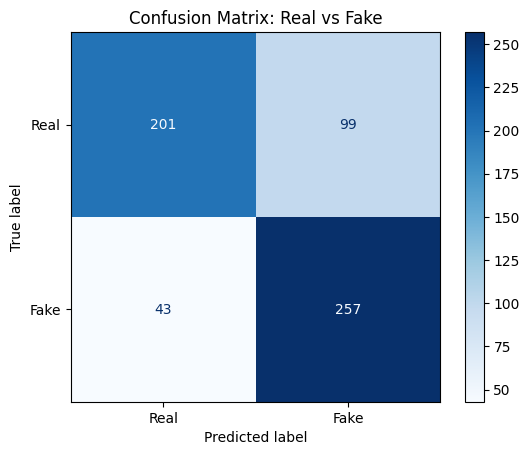

In [8]:
# --- Confusion Matrix ---
cm = confusion_matrix(true_labels, pred_labels, labels=[LABEL_REAL, LABEL_FAKE])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Real", "Fake"])

plt.figure(figsize=(8, 6))
disp.plot(cmap=plt.cm.Blues, values_format="d")
plt.title("Confusion Matrix: Real vs Fake")
plt.savefig("confusion_matrix_final.png")
plt.show()


Area Under the Curve (AUC): 0.8734


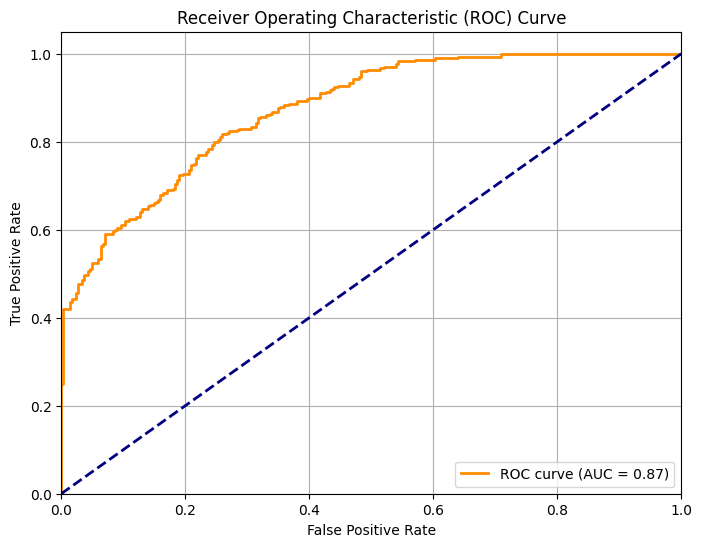

In [9]:
# --- AUC (fake is positive class) ---
try:
    auc_score = roc_auc_score(true_labels, prob_fake_scores)
    print(f"Area Under the Curve (AUC): {auc_score:.4f}")

    fpr, tpr, _ = roc_curve(true_labels, prob_fake_scores)
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC curve (AUC = {auc_score:.2f})")
    plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("Receiver Operating Characteristic (ROC) Curve")
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.savefig("roc_curve_final.png")
    plt.show()
except ValueError as e:
    print(f"Could not calculate AUC: {e}")